<a href="https://colab.research.google.com/github/ciril7/AI-ML-Intern/blob/main/Boston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import sklearn.preprocessing

In [2]:
df=pd.read_csv('/content/boston.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [4]:
encoder_data=df.copy()

In [5]:
df['age_mean_imputed']=df['age'].fillna(df['age'])

In [6]:
df['age_median_imputed']=df['age'].fillna(df['age'].median())

In [7]:
df['tax_mode_imputed']=df['tax'].fillna(df['tax'].mode()[0])

In [8]:
df[['age','age_mean_imputed','age_median_imputed']]

,age,age_mean_imputed,age_median_imputed
0,65.2,65.2,65.2
1,78.9,78.9,78.9
2,61.1,61.1,61.1
3,45.8,45.8,45.8
4,54.2,54.2,54.2
...,...,...,...
501,69.1,69.1,69.1
502,76.7,76.7,76.7
503,91.0,91.0,91.0
504,89.3,89.3,89.3


In [9]:
import matplotlib.pyplot as plt

In [10]:
sns.set(style="whitegrid")

/tmp/ipykernel_3090/3183086075.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='rad',y='ptratio',palette='Set3')


Text(0, 0.5, 'ptratio')

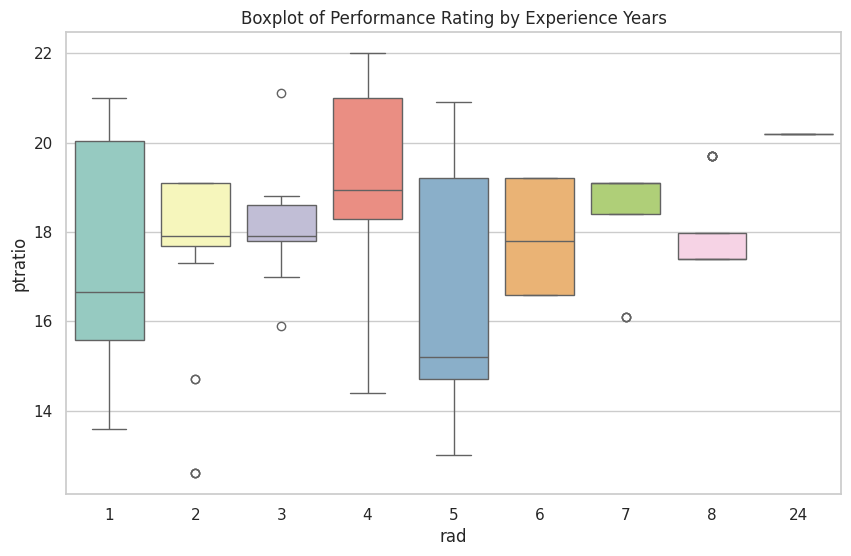

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='rad',y='ptratio',palette='Set3')
plt.title('Boxplot of Performance Rating by Experience Years')
plt.xlabel('rad')
plt.ylabel('ptratio')

/tmp/ipykernel_3090/4240688216.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='rad',y='ptratio',palette='muted')


Text(0, 0.5, 'ptratio')

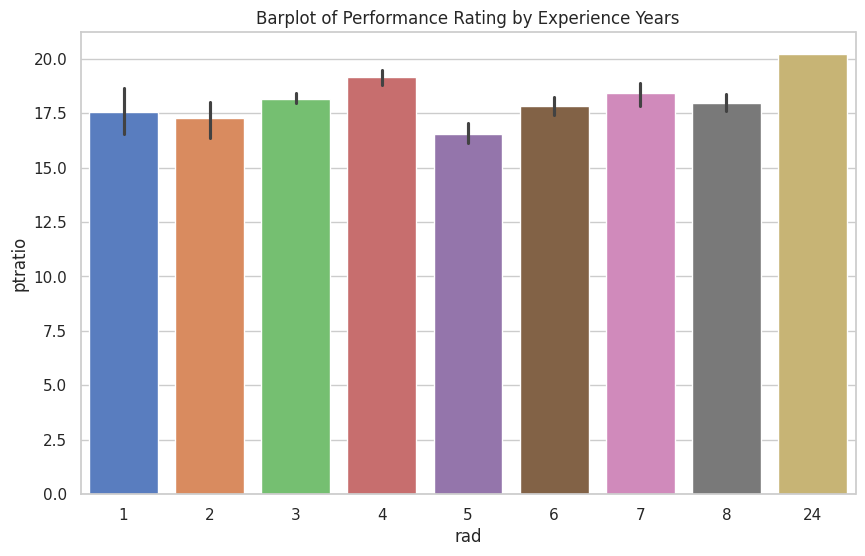

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='rad',y='ptratio',palette='muted')
plt.title('Barplot of Performance Rating by Experience Years')
plt.xlabel('rad')
plt.ylabel('ptratio')

/tmp/ipykernel_3090/97058352.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df,x='rad',y='ptratio',palette='muted')


Text(0, 0.5, 'ptratio')

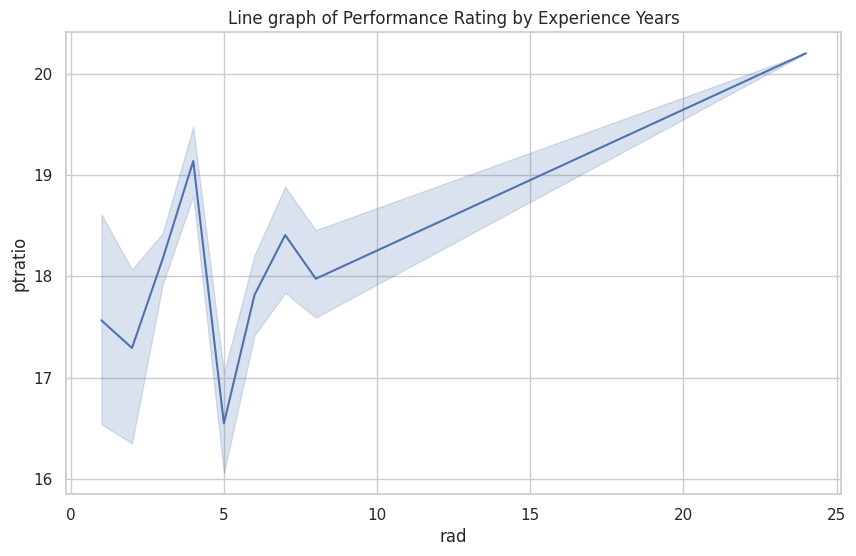

In [13]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df,x='rad',y='ptratio',palette='muted')
plt.title('Line graph of Performance Rating by Experience Years')
plt.xlabel('rad')
plt.ylabel('ptratio')

/tmp/ipykernel_3090/2917517358.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x='rad',y='ptratio',palette='muted')


Text(0, 0.5, 'ptratio')

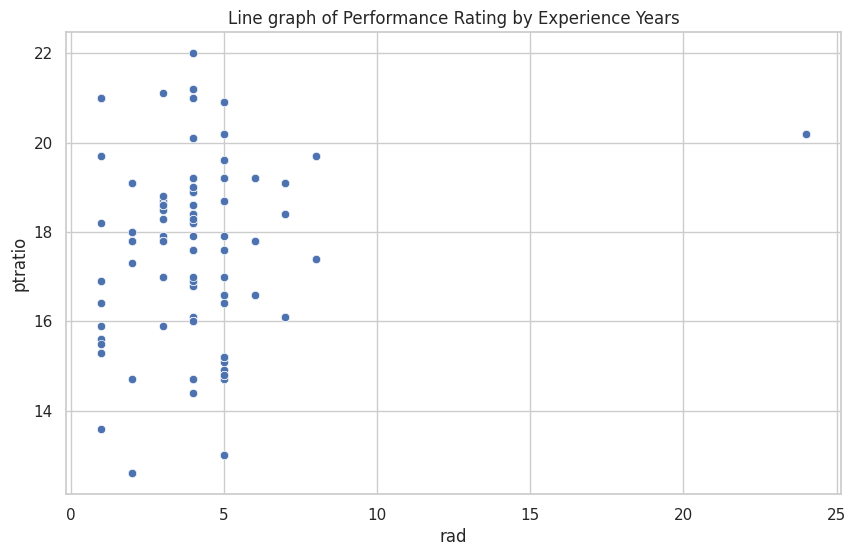

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='rad',y='ptratio',palette='muted')
plt.title('Line graph of Performance Rating by Experience Years')
plt.xlabel('rad')
plt.ylabel('ptratio')

/tmp/ipykernel_3090/3497667214.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df,x='rad',y='ptratio',palette='muted')


Text(0, 0.5, 'ptratio')

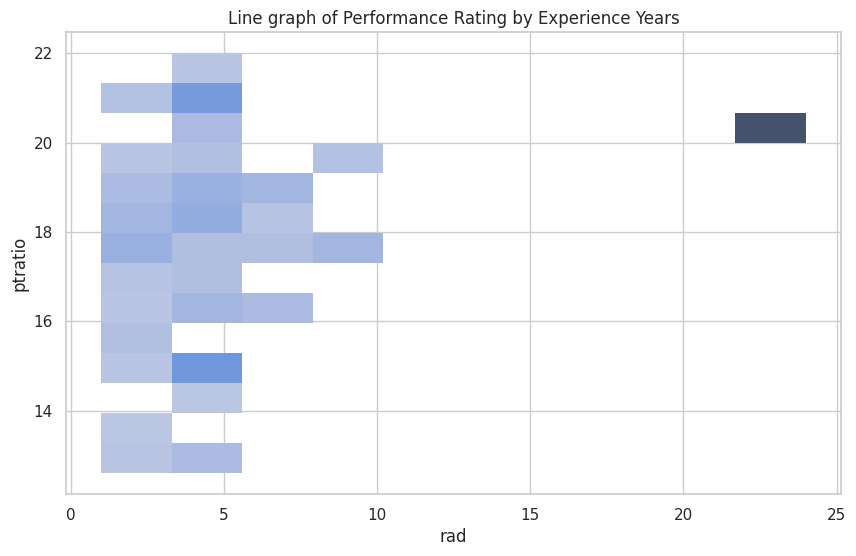

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='rad',y='ptratio',palette='muted')
plt.title('Line graph of Performance Rating by Experience Years')
plt.xlabel('rad')
plt.ylabel('ptratio')

In [16]:
encoded_data=df.copy()

In [17]:
one_hot_encoded = pd.get_dummies(encoded_data['rad'], prefix='rad')
encoded_data = pd.concat([encoded_data, one_hot_encoded], axis=1)

ptratio_mapping = {1: 'First', 2: 'Second', 3: 'Third', 4: 'Fourth',5:'Fifth'}
encoded_data['ptratio_Category'] = encoded_data['ptratio'].map(ptratio_mapping)

print(encoded_data[['age', 'rad', 'ptratio', 'ptratio_Category']].head())

    age  rad  ptratio ptratio_Category
0  65.2    1     15.3              NaN
1  78.9    2     17.8              NaN
2  61.1    2     17.8              NaN
3  45.8    3     18.7              NaN
4  54.2    3     18.7              NaN


In [18]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler

In [19]:
numerical_columns=['age','ptratio']

In [20]:
df.dropna(subset=numerical_columns,inplace=True)

In [21]:
minmax_scaler=MinMaxScaler()
standard_scaler=StandardScaler()
robust_scaler=RobustScaler()

In [22]:
df['age_MinMax']=minmax_scaler.fit_transform(df[['age']])
df['ptratio_MinMax']=minmax_scaler.fit_transform(df[['ptratio']])

In [23]:
df['age_Standard']=minmax_scaler.fit_transform(df[['age']])
df['ptratio_Standard']=minmax_scaler.fit_transform(df[['ptratio']])

In [24]:
df['age_Robust']=minmax_scaler.fit_transform(df[['age']])
df['ptratio_Robust']=minmax_scaler.fit_transform(df[['ptratio']])

In [25]:
df[['age','age_MinMax','age_Standard','age_Robust']]

,age,age_MinMax,age_Standard,age_Robust
0,65.2,0.641607,0.641607,0.641607
1,78.9,0.782698,0.782698,0.782698
2,61.1,0.599382,0.599382,0.599382
3,45.8,0.441813,0.441813,0.441813
4,54.2,0.528321,0.528321,0.528321
...,...,...,...,...
501,69.1,0.681771,0.681771,0.681771
502,76.7,0.760041,0.760041,0.760041
503,91.0,0.907312,0.907312,0.907312
504,89.3,0.889804,0.889804,0.889804


In [26]:
from sklearn.model_selection import train_test_split

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
from sklearn.metrics import mean_squared_error,r2_score

In [29]:
X=df.drop(columns=["medv"])

In [30]:
Y=df["medv"]

In [31]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [32]:
model=LinearRegression()

In [33]:
model.fit(X_train,Y_train)

LinearRegression()

In [34]:
Y_pred=model.predict(X_test)

In [35]:
r2=r2_score(Y_test,Y_pred)

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["medv"])  # All columns except target
y = df["medv"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.6688
RMSE: 4.9286
